In [4]:
import pandas as pd

df = pd.read_csv('/content/classData.csv')
display(df.head())

,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983


In [5]:
def assign_class_label(row):
    g, c, b, a = row['G'], row['C'], row['B'], row['A']
    if g == 0 and c == 0 and b == 0 and a == 0:
        return 0
    elif g == 1 and c == 0 and b == 0 and a == 1:
        return 1
    elif g == 0 and c == 0 and b == 1 and a == 1:
        return 2
    elif g == 1 and c == 0 and b == 1 and a == 1:
        return 3
    elif g == 0 and c == 1 and b == 1 and a == 1:
        return 4
    elif g == 1 and c == 1 and b == 1 and a == 1:
        return 5
    else:
        return 6 # For any other unmapped combination

df['class_label'] = df.apply(assign_class_label, axis=1)

print("Value counts for the new 'class_label' column:")
print(df['class_label'].value_counts())

display(df.head())

Value counts for the new 'class_label' column:
class_label
0    2365
3    1134
5    1133
1    1129
4    1096
6    1004
Name: count, dtype: int64


,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc,class_label
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815,1
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099,1
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428,1
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570,1
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983,1


In [6]:
df = df.drop(columns=['G', 'C', 'B', 'A'])

print("DataFrame after dropping original fault columns:")
display(df.head())

DataFrame after dropping original fault columns:


,Ia,Ib,Ic,Va,Vb,Vc,class_label
0,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815,1
1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099,1
2,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428,1
3,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570,1
4,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983,1


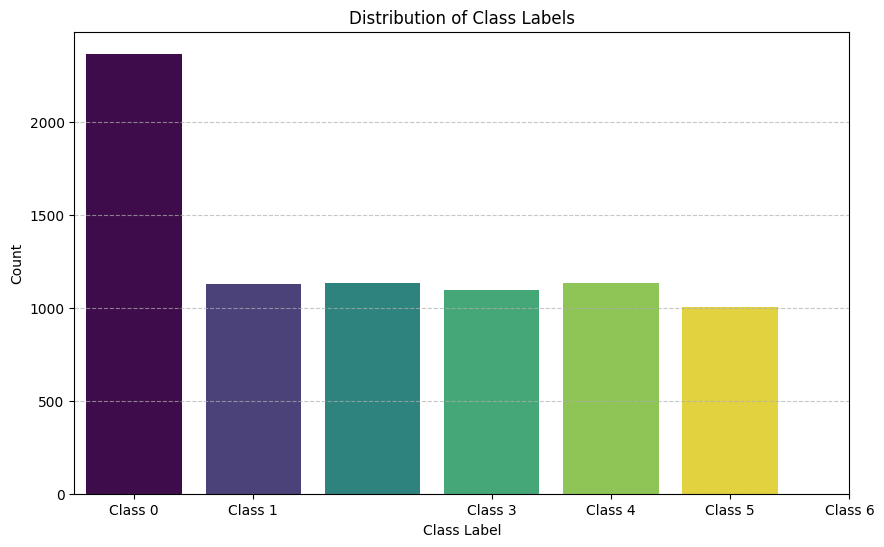


Counts of each Class Label:
class_label
0    2365
1    1129
3    1134
4    1096
5    1133
6    1004
Name: count, dtype: int64


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the counts of each class_label
class_label_counts = df['class_label'].value_counts().sort_index()

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=class_label_counts.index, y=class_label_counts.values, palette='viridis', hue=class_label_counts.index, legend=False)

# Add labels and title
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.title('Distribution of Class Labels')
plt.xticks(ticks=class_label_counts.index, labels=[f'Class {int(i)}' for i in class_label_counts.index])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print('\nCounts of each Class Label:')
print(class_label_counts)

/tmp/ipykernel_9030/2469409340.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class_label', y=col, data=df, ax=axes[i], palette='viridis')
/tmp/ipykernel_9030/2469409340.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class_label', y=col, data=df, ax=axes[i], palette='viridis')
/tmp/ipykernel_9030/2469409340.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class_label', y=col, data=df, ax=axes[i], palette='viridis')
/tmp/ipykernel_9030/2469409340.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is dep

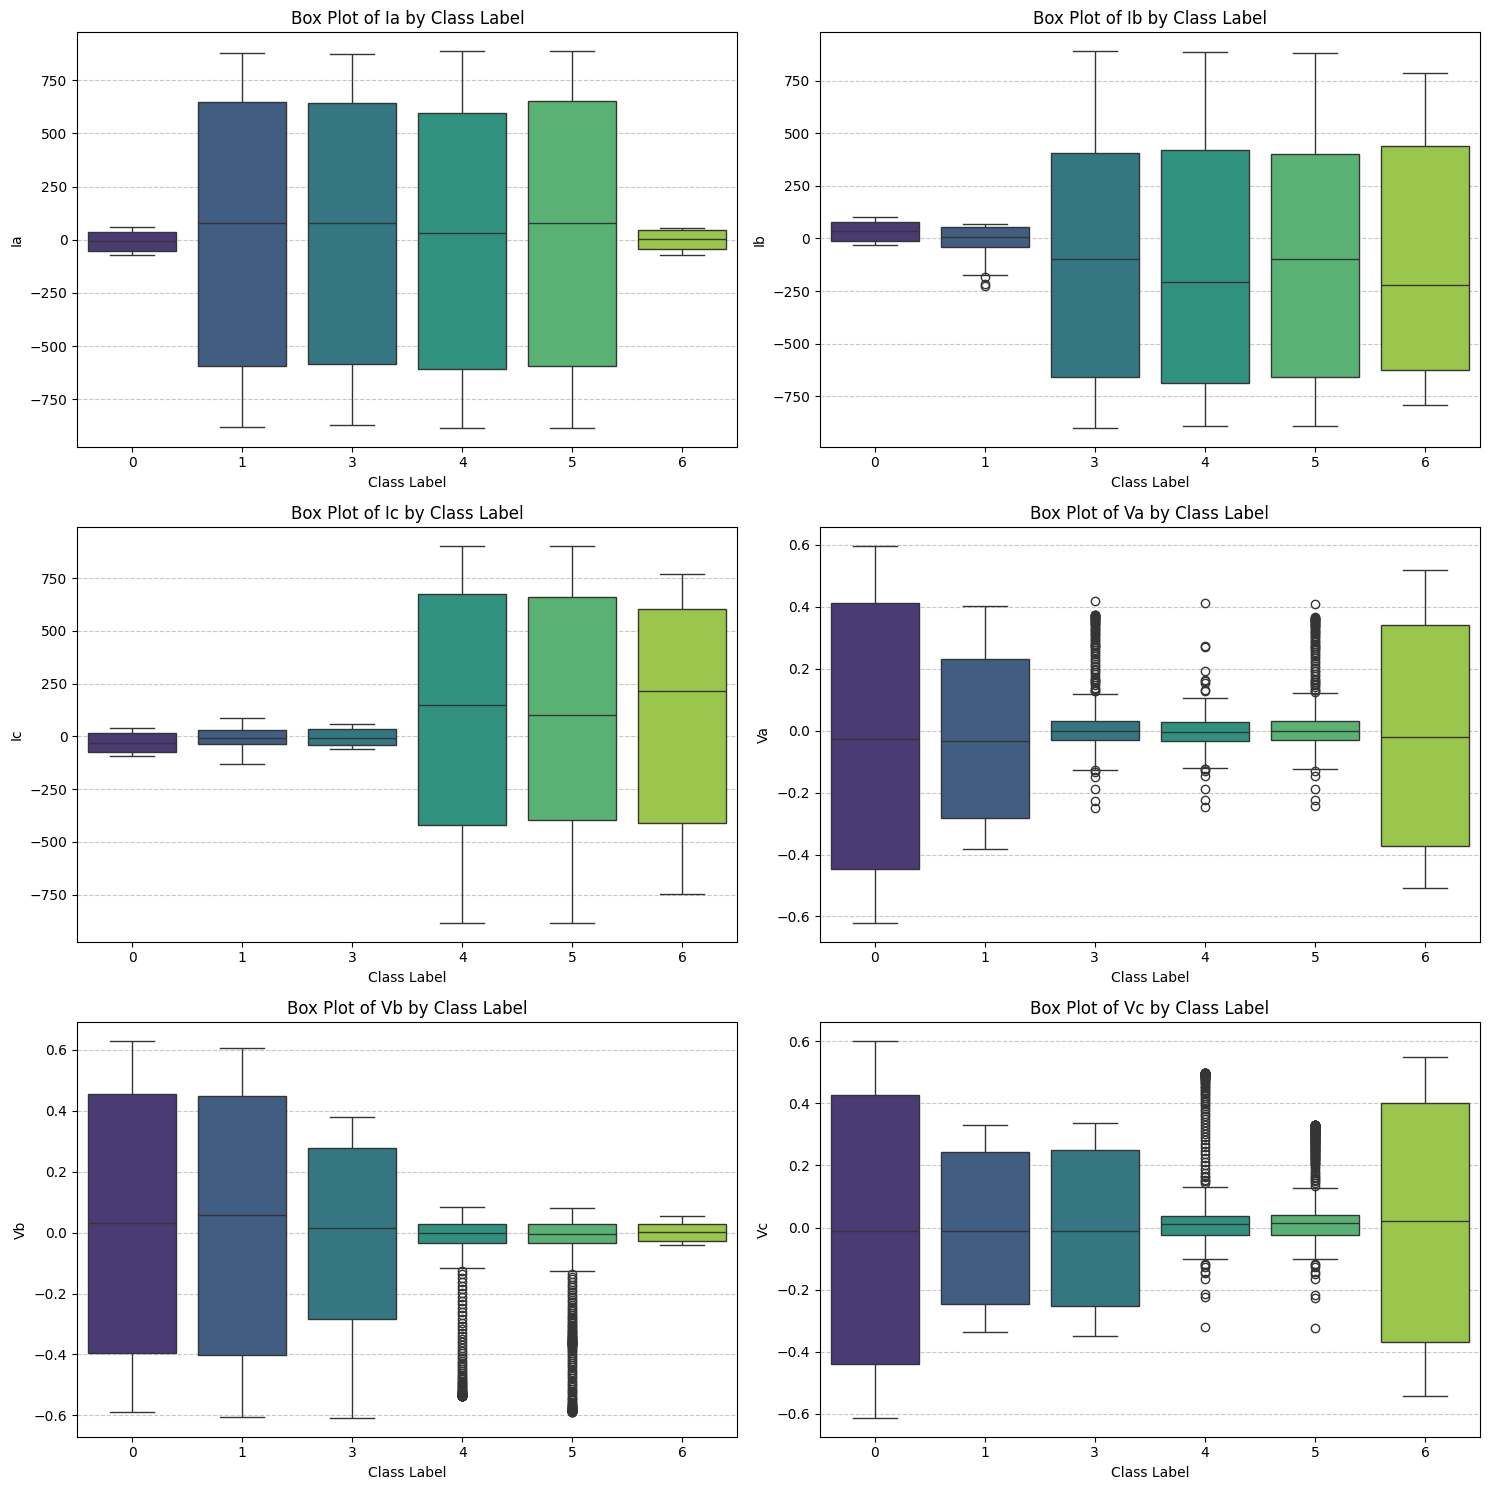

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for box plotting, excluding 'class_label'
numerical_cols = ['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']

# Create subplots for each numerical column
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x='class_label', y=col, data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Box Plot of {col} by Class Label')
    axes[i].set_xlabel('Class Label')
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Outlier Detection using IQR

Let's identify potential outliers in our numerical features using the Interquartile Range (IQR) method. Data points falling below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR will be considered outliers.

In [9]:
numerical_cols = ['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']
outliers = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers for the current column
    col_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers[col] = col_outliers

    print(f"\nOutliers in '{col}':")
    print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print(f"Number of outliers: {len(col_outliers)}")
    if not col_outliers.empty:
        display(col_outliers[['class_label', col]].head()) # Display first few outliers if any


Outliers in 'Ia':
Lower Bound: -640.38, Upper Bound: 747.82
Number of outliers: 1802


,class_label,Ia
4,1,-643.663617
14,1,-668.714740
15,1,-695.776289
16,1,-689.362058
17,1,-657.620238



Outliers in 'Ib':
Lower Bound: -816.41, Upper Bound: 635.75
Number of outliers: 1216


,class_label,Ib
1271,3,-820.139549
1272,3,-825.756055
1273,3,-831.344811
1274,3,-836.781528
1275,3,-841.932951



Outliers in 'Ic':
Lower Bound: -226.26, Upper Bound: 214.34
Number of outliers: 2524


...


Outliers in 'Va':
Lower Bound: -0.49, Upper Bound: 0.47
Number of outliers: 1160


,class_label,Va
2263,6,0.517510
2264,6,0.518491
2265,6,0.511217
2266,6,0.499096
2267,6,0.487527



Outliers in 'Vb':
Lower Bound: -0.63, Upper Bound: 0.62
Number of outliers: 71


,class_label,Vb
5671,0,0.624146
5672,0,0.625126
5673,0,0.625957
5674,0,0.626639
5675,0,0.627172



Outliers in 'Vc':
Lower Bound: -0.90, Upper Bound: 0.92
Number of outliers: 0


In [10]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('class_label', axis=1)
y = df['class_label']

# Split the data into training and testing sets
# Using a 80/20 split, stratify by y to maintain class distribution, and a random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (6288, 6)
X_test shape: (1573, 6)
y_train shape: (6288,)
y_test shape: (1573,)


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

print("\n--- SVM with RBF Kernel ---")

# Initialize the SVM classifier with the RBF kernel
svm_model_rbf = SVC(kernel='rbf', random_state=42)

# Train the model
svm_model_rbf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rbf = svm_model_rbf.predict(X_test)

# Print the classification report
print(classification_report(y_test, y_pred_rbf, zero_division=0))

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

print("\n--- SVM with Polynomial Kernel (degree=3) ---")

# Initialize the SVM classifier with the Polynomial kernel
svm_model_poly = SVC(kernel='poly', random_state=42, degree=3)

# Train the model
svm_model_poly.fit(X_train, y_train)

# Make predictions on the test set
y_pred_poly = svm_model_poly.predict(X_test)

# Print the classification report
print(classification_report(y_test, y_pred_poly, zero_division=0))

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

print("\n--- Random Forest Classifier ---")

# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Print the classification report
print(classification_report(y_test, y_pred_rf, zero_division=0))

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Define a range of max_depth values to experiment with
depths_to_try = [5, 10, 15, 20, None] # None means full depth

best_accuracy = 0
best_depth = None

print("\n--- Random Forest Classifier Hyperparameter Tuning (max_depth) ---")

for depth in depths_to_try:
    print(f"\n--- Training Random Forest with max_depth={depth if depth is not None else 'None (full depth)'} ---")

    # Initialize the Random Forest Classifier with the current max_depth
    rf_model_tuned = RandomForestClassifier(max_depth=depth, random_state=42)

    # Train the model
    rf_model_tuned.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred_tuned = rf_model_tuned.predict(X_test)

    # Print the classification report
    report = classification_report(y_test, y_pred_tuned, zero_division=0, output_dict=True)
    print(classification_report(y_test, y_pred_tuned, zero_division=0))

    current_accuracy = report['accuracy']
    if current_accuracy > best_accuracy:
        best_accuracy = current_accuracy
        best_depth = depth

print(f"\n--- Hyperparameter Tuning Results ---")
print(f"Best accuracy achieved: {best_accuracy:.4f}")
print(f"Optimal max_depth: {best_depth if best_depth is not None else 'None (full depth)'}")

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

print("\n--- Light Gradient Boosting Machine (LGBM) Classifier ---")

# Initialize the LGBM Classifier
lgbm_model = LGBMClassifier(random_state=42)

# Train the model
lgbm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lgbm = lgbm_model.predict(X_test)

# Print the classification report
print(classification_report(y_test, y_pred_lgbm, zero_division=0))

In [ ]:
import pandas as pd
df = pd.read_csv('/content/classData.csv')
display(df.head())